# Natural response study: SEI EC/VC concentrations

2026-02-12

Study the natural response of model voltage, current, and expansion-related states to changes in SEI (EC/VC) concentrations, using the base formation protocol and follow-on charge/discharge steps.

**Protocol overview**
- Run the usual **base formation** protocol explicitly via `cellsim.Simulation`.
- After formation, **discharge to 3.0 V**, then **charge to 4.0 V**, then **rest 2 h**.
- After this rest, **halve the VC (SEI2) concentration**, then **rest another 2 h**.
- Then **charge again to 4.0 V**, **rest 2 h**, and finally **halve the EC (SEI1) concentration** (optionally followed by an additional rest to observe the response).

We will then plot:
- Voltage vs. time
- Current vs. time
- EC and VC concentrations vs. time (with a secondary y-axis)
- Expansion vs. time

Vertical lines will indicate when the VC and EC concentrations are updated.


In [14]:
import os, sys

# Make project root importable if running from notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
    sys.path.insert(0, "src/")

from src import cellsim
from src import plotter
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

%load_ext autoreload
%autoreload 2
%matplotlib widget

plotter.initialize(plt)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
# Set up cell and simulation
cell = cellsim.Cell()
cell.load_config("params/default.yaml")

# Simulation settings
dt = 0.1  # [s]
total_time_hours = 300.0  # generous upper bound
sim = cellsim.Simulation(cell, int(total_time_hours * 3600), dt=dt)

# Convenience aliases for currents and voltage limits
vmax_formation = 4.2
vmin = 3.0
I_chg = 2.5 / 10.0
I_chg_cv = 2.5 / 20.0
I_dch = -2.5 / 10.0
I_dch_cv = -2.5 / 10.0

# --- Base formation protocol (mirrors simutils.run_sim(..., formation_type='base')) ---

sim.run_rest(1, rest_time_hrs=0.5)

# sim.run_chg_cccv(2, I_chg, I_chg_cv, vmax_formation)
sim.run_chg_cccv(2, I_chg, I_chg_cv, 3.0)
# sim.run_rest(2, rest_time_hrs=1.0 / 6.0)
# sim.run_dch_cccv(2, I_dch, I_dch_cv, vmin)
# sim.run_rest(2, rest_time_hrs=1.0 / 6.0)

# sim.run_chg_cccv(3, I_chg, I_chg_cv, vmax_formation)
# sim.run_rest(3, rest_time_hrs=1.0 / 6.0)
# sim.run_dch_cccv(3, I_dch, I_dch_cv, vmin)
# sim.run_rest(3, rest_time_hrs=1.0 / 6.0)

# sim.run_chg_cccv(4, I_chg, I_chg_cv, vmax_formation)
# sim.run_rest(4, rest_time_hrs=1.0 / 6.0)
# sim.run_dch_cccv(4, I_dch, 0.05, vmin)
# sim.run_rest(4, rest_time_hrs=1.0 / 6.0)

# Extra discharge and long rest as in base protocol
# sim.run_dch_cccv(4, I_dch, 0.05, vmin)
# sim.run_rest(4, rest_time_hrs=6.0)

print(f"Formation complete at t = {sim.t[sim.curr_k] / 3600:.2f} h")


Formation complete at t = 0.91 h


In [22]:
# Helper to record parameter-change events for plotting
event_times_hours = []
event_labels = []

def record_event(label: str):
    t_hr = sim.t[sim.curr_k] / 3600.0
    event_times_hours.append(t_hr)
    event_labels.append(label)
    print(f"{label} at t = {t_hr:.2f} h (curr_k = {sim.curr_k})")

def scale_sei_concentration(simulation: cellsim.Simulation, species: str, factor: float):
    """Scale EC/VC SEI concentrations at the current time index by a factor."""
    k = simulation.curr_k
    if species.lower() in {"vc", "sei2"}:
        simulation.c_sei2[k] *= factor
    elif species.lower() in {"ec", "sei1"}:
        simulation.c_sei1[k] *= factor
    else:
        raise ValueError(f"Unknown species '{species}'. Expected 'EC' or 'VC'.")

# --- Post-formation protocol ---

# 1) After formation: discharge to 3.0 V, then charge to 4.0 V, then rest 2 h
vmax_4 = 3.0
I_chg_4V = I_chg
I_chg_4V_cv = I_chg_cv

sim.run_rest(5, rest_time_hrs=2.0)

# 2) After this 2 h rest: halve VC (SEI2) concentration, then rest another 2 h
scale_sei_concentration(sim, species="VC", factor=0.5)
record_event("VC concentration ×0.5")

sim.run_rest(5, rest_time_hrs=2.0)

# 3) Charge again to 4.0 V, rest 2 h, then halve EC (SEI1) concentration
sim.run_chg_cccv(6, I_chg_4V, I_chg_4V_cv, vmax_4)
sim.run_rest(6, rest_time_hrs=2.0)

scale_sei_concentration(sim, species="EC", factor=0.5)
record_event("EC concentration ×0.5")

# Optional: rest again to observe natural response after EC change
sim.run_rest(6, rest_time_hrs=2.0)

print(f"Final time = {sim.t[sim.curr_k] / 3600:.2f} h, total steps = {sim.curr_k}")

df = sim.get_results()
df.head()


VC concentration ×0.5 at t = 2.91 h (curr_k = 104757)
EC concentration ×0.5 at t = 6.97 h (curr_k = 250995)
Final time = 8.97 h, total steps = 322995


,name,cell,dt,t,curr_k,i_app,cycle_number,step_number,theta_n,theta_p,...,i_sei,q_sei,R_sei1,R_sei2,R_sei,rho_sei,dq,dqsei,dqsei1,dqsei2
0,DefaultSim,<src.cellsim.Cell object at 0x12b8cb320>,0.1,0.0,322995,0.0,1.0,4.0,0.000000e+00,1.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000153,0.000153,NaN,0.0,0.000000e+00,0.000000e+00,0.000000e+00
1,DefaultSim,<src.cellsim.Cell object at 0x12b8cb320>,0.1,0.1,322995,0.0,1.0,4.0,0.000000e+00,1.0,...,4.951336e-25,1.375371e-29,8.259545e-35,0.000153,0.000153,1.3,0.0,1.375371e-29,3.102475e-33,1.375061e-29
2,DefaultSim,<src.cellsim.Cell object at 0x12b8cb320>,0.1,0.2,322995,0.0,1.0,4.0,-4.380163e-30,1.0,...,4.951336e-25,2.750742e-29,1.651909e-34,0.000153,0.000153,1.3,0.0,1.375371e-29,3.102475e-33,1.375061e-29
3,DefaultSim,<src.cellsim.Cell object at 0x12b8cb320>,0.1,0.3,322995,0.0,1.0,4.0,-8.760326e-30,1.0,...,4.951336e-25,4.126113e-29,2.477863e-34,0.000153,0.000153,1.3,0.0,1.375371e-29,3.102475e-33,1.375061e-29
4,DefaultSim,<src.cellsim.Cell object at 0x12b8cb320>,0.1,0.4,322995,0.0,1.0,4.0,-1.314049e-29,1.0,...,4.951336e-25,5.501485e-29,3.303818e-34,0.000153,0.000153,1.3,0.0,1.375371e-29,3.102475e-33,1.375061e-29


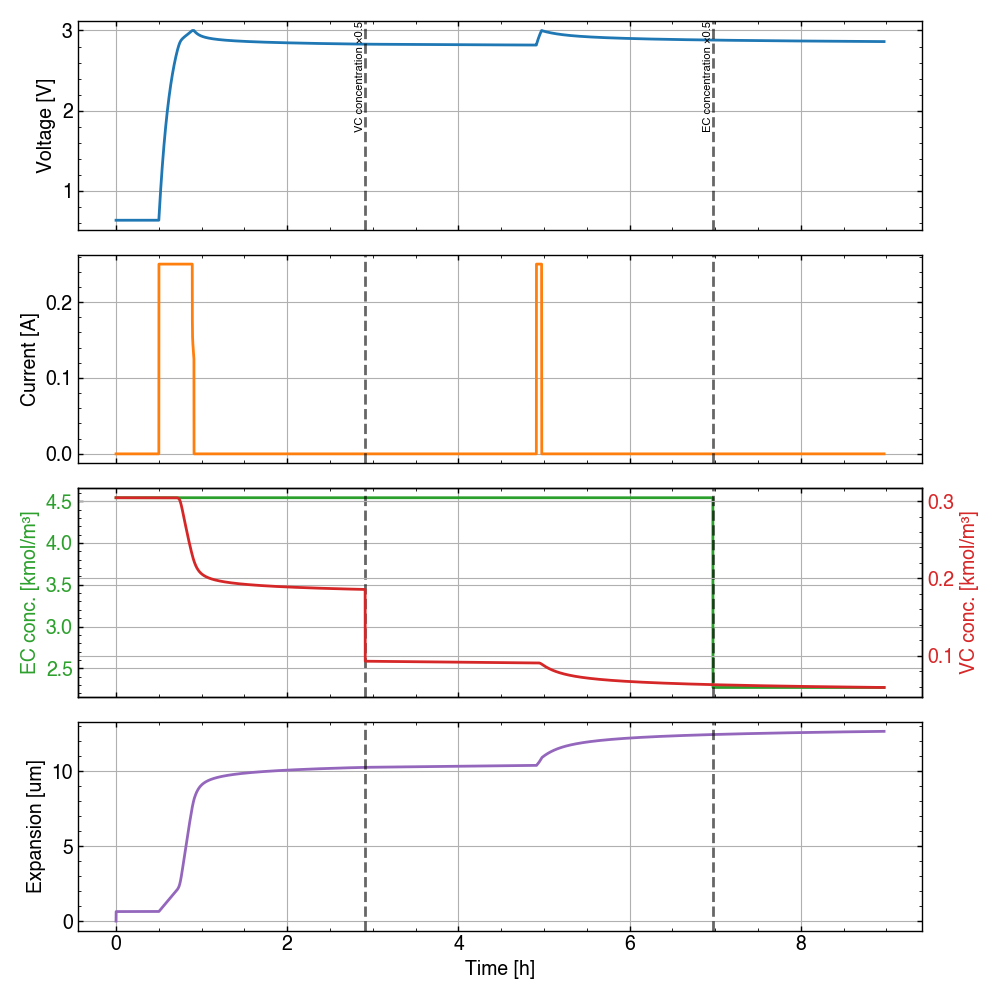

In [23]:
# Plot voltage, current, SEI EC/VC concentrations, and expansion with parameter-change markers

t_hr = df["t"] / 3600.0

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

# Voltage
axes[0].plot(t_hr, df["vt"], color="C0")
axes[0].set_ylabel("Voltage [V]")
axes[0].grid(True)

# Current
axes[1].plot(t_hr, df["i_app"], color="C1")
axes[1].set_ylabel("Current [A]")
axes[1].grid(True)

# SEI concentrations: EC (SEI1) and VC (SEI2)
ax3 = axes[2]
ax3b = ax3.twinx()

ax3.plot(t_hr, df["c_sei1"] / 1e3, color="C2", label="EC (SEI1)")
ax3.set_ylabel("EC conc. [kmol/m³]", color="C2")
ax3.tick_params(axis="y", labelcolor="C2")

ax3b.plot(t_hr, df["c_sei2"] / 1e3, color="C3", label="VC (SEI2)")
ax3b.set_ylabel("VC conc. [kmol/m³]", color="C3")
ax3b.tick_params(axis="y", labelcolor="C3")
axes[2].grid(True)

# Expansion
axes[3].plot(t_hr, df["expansion"]*1e6, color="C4")
axes[3].set_ylabel("Expansion [um]")
axes[3].set_xlabel("Time [h]")
axes[3].grid(True)

# Add vertical lines for parameter updates
for t_evt, label in zip(event_times_hours, event_labels):
    for ax in axes:
        ax.axvline(t_evt, color="k", linestyle="--", alpha=0.6)
    axes[0].text(t_evt, axes[0].get_ylim()[1], label,
                 rotation=90, fontsize=8, va="top", ha="right")

plt.tight_layout()
plt.show()
